# In Class May 19

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

/Users/shanewaldron/Desktop/MSBA/GSB 545/In-Class Assignments/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Importing the data

In [2]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

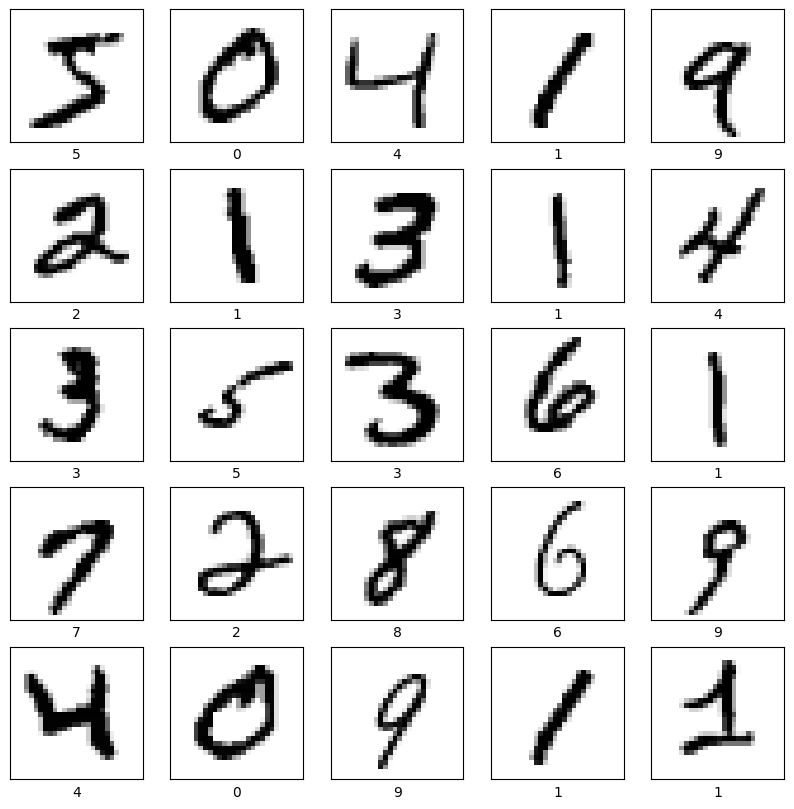

In [4]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [5]:
# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [6]:
# Define the MLP model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8261 - loss: 0.6272 - val_accuracy: 0.9568 - val_loss: 0.1492
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9565 - loss: 0.1446 - val_accuracy: 0.9705 - val_loss: 0.1055
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.0991 - val_accuracy: 0.9730 - val_loss: 0.0961
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0725 - val_accuracy: 0.9772 - val_loss: 0.0870
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9818 - loss: 0.0585 - val_accuracy: 0.9757 - val_loss: 0.0844
313/313 - 0s - 605us/step - accuracy: 0.9746 - loss: 0.0823
MLP Test accuracy: 0.9746


### Preparing data for CNN

In [8]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [9]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [10]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8833 - loss: 0.3916 - val_accuracy: 0.9805 - val_loss: 0.0752
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9786 - loss: 0.0718 - val_accuracy: 0.9837 - val_loss: 0.0553
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9866 - loss: 0.0455 - val_accuracy: 0.9835 - val_loss: 0.0589
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9901 - loss: 0.0309 - val_accuracy: 0.9872 - val_loss: 0.0486
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9930 - loss: 0.0227 - val_accuracy: 0.9872 - val_loss: 0.0624


### Evaluating the CNN model

In [11]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9802 - loss: 0.0615
CNN Test Accuracy: 0.984000027179718


### MLP vs CNN model

In [12]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")                      


MLP Test accuracy: 0.9746
CNN Test accuracy: 0.9840


### Visualizing model training

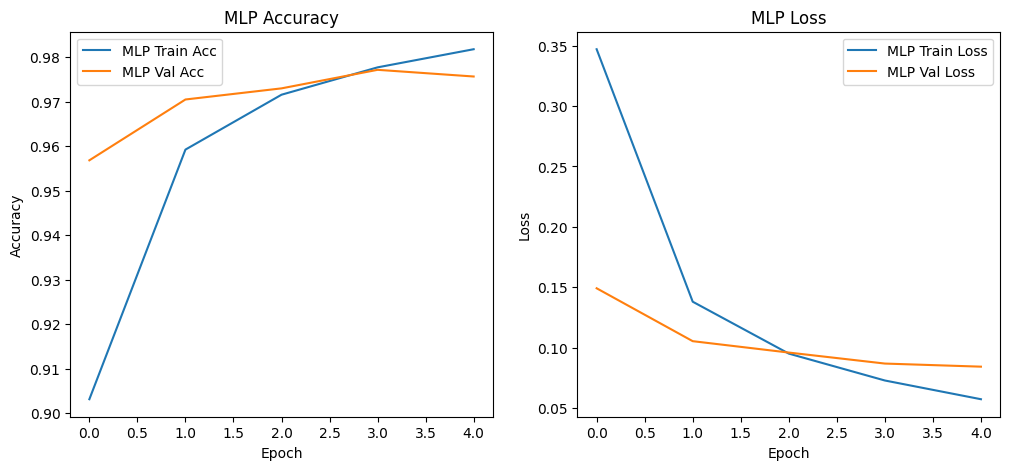

In [13]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


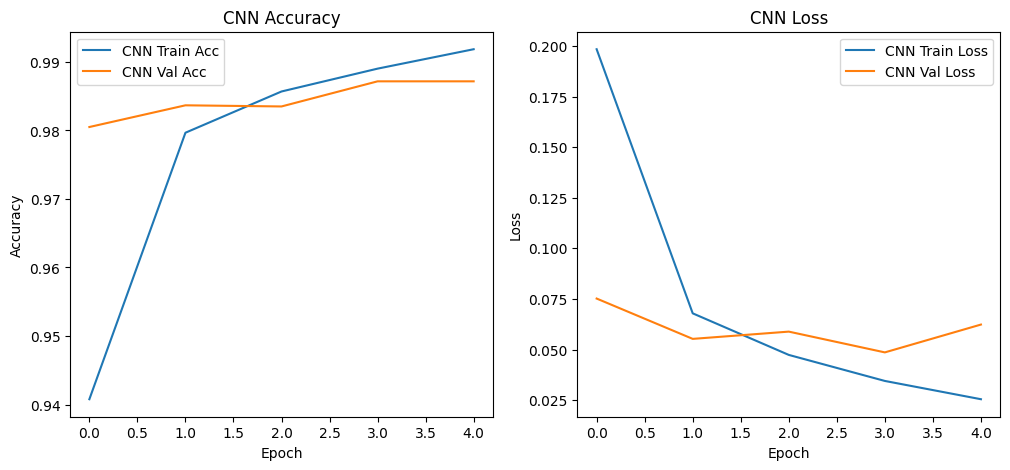

In [14]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


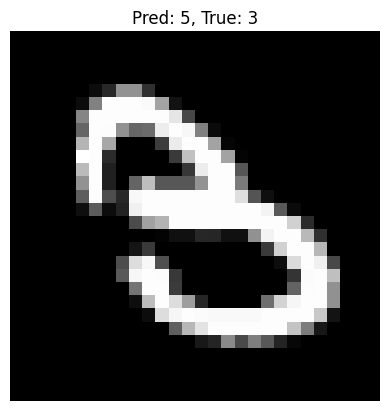

In [15]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

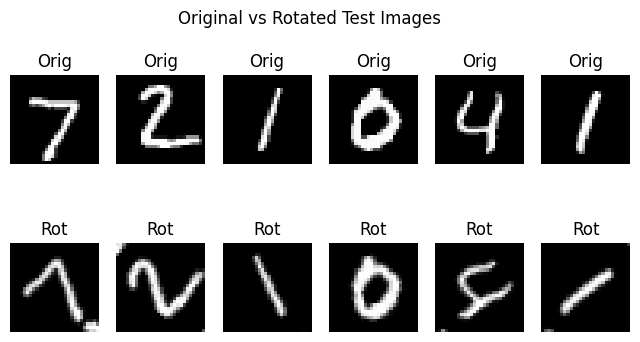

In [16]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [17]:
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step - accuracy: 0.7107 - loss: 1.3661
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7577 - loss: 1.2080
MLP accuracy (original test): 0.9746000170707703
MLP accuracy (rotated test): 0.7157999873161316
CNN accuracy (original test): 0.984000027179718
CNN accuracy (rotated test): 0.7584999799728394


### New models trained with data augmentation (random rotations)

In [18]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [19]:
# Retrain MLP on rotated data
mlp_model_rot = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
mlp_model_rot.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_mlp_rot = mlp_model_rot.fit(
    X_train_rot_train_flat,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7205 - loss: 0.9254 - val_accuracy: 0.9132 - val_loss: 0.2914
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9080 - loss: 0.3073 - val_accuracy: 0.9358 - val_loss: 0.2153
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9346 - loss: 0.2213 - val_accuracy: 0.9427 - val_loss: 0.1892
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.1691 - val_accuracy: 0.9503 - val_loss: 0.1748
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9537 - loss: 0.1521 - val_accuracy: 0.9508 - val_loss: 0.1661


### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

In [20]:
# retrain CNN on rotated data
cnn_model_rot = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
cnn_model_rot.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_cnn_rot = cnn_model_rot.fit(
    X_train_rot_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7599 - loss: 0.7900 - val_accuracy: 0.9413 - val_loss: 0.1986
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9375 - loss: 0.2124 - val_accuracy: 0.9587 - val_loss: 0.1406
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9537 - loss: 0.1466 - val_accuracy: 0.9683 - val_loss: 0.1119
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9661 - loss: 0.1093 - val_accuracy: 0.9697 - val_loss: 0.1039
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9728 - loss: 0.0879 - val_accuracy: 0.9713 - val_loss: 0.0927


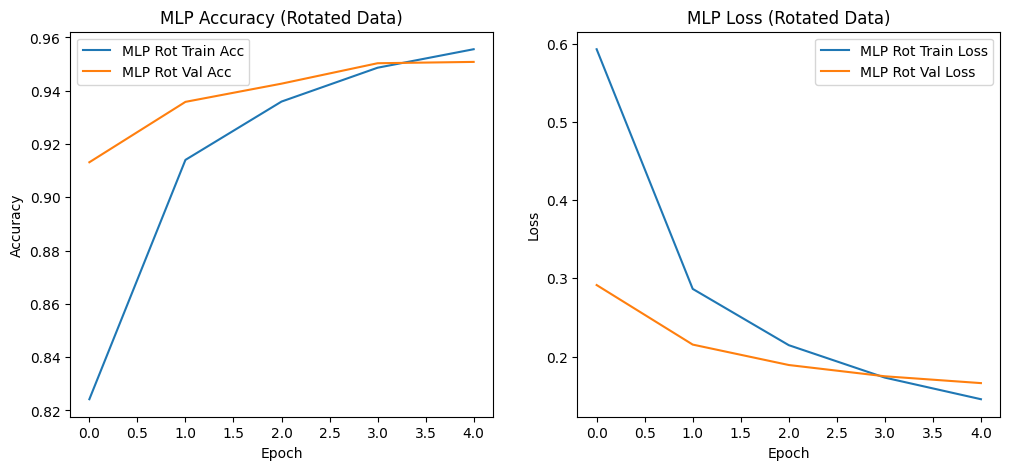

In [21]:
# plot training history for MLP retrained on rotated data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp_rot.history['accuracy'], label='MLP Rot Train Acc')
plt.plot(history_mlp_rot.history['val_accuracy'], label='MLP Rot Val Acc')
plt.title('MLP Accuracy (Rotated Data)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_mlp_rot.history['loss'], label='MLP Rot Train Loss')
plt.plot(history_mlp_rot.history['val_loss'], label='MLP Rot Val Loss')
plt.title('MLP Loss (Rotated Data)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

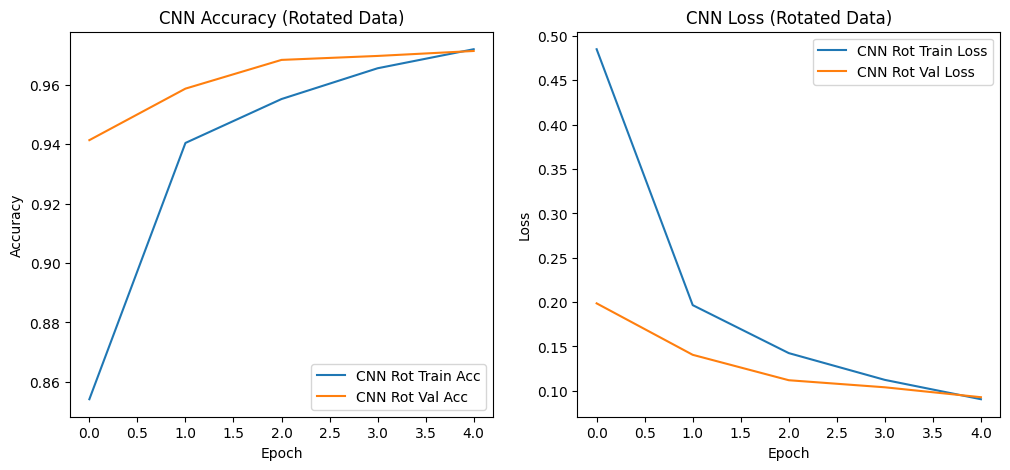

In [22]:
# plot training history for CNN retrained on rotated data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn_rot.history['accuracy'], label='CNN Rot Train Acc')
plt.plot(history_cnn_rot.history['val_accuracy'], label='CNN Rot Val Acc')
plt.title('CNN Accuracy (Rotated Data)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()    
plt.subplot(1, 2, 2)
plt.plot(history_cnn_rot.history['loss'], label='CNN Rot Train Loss')
plt.plot(history_cnn_rot.history['val_loss'], label='CNN Rot Val Loss')
plt.title('CNN Loss (Rotated Data)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.

### MLP vs. CNN

The CNN performed better than the MLP overall. On the original test set, the MLP reached 97.46% accuracy, while the CNN reached 98.40%.

The CNN also held up slightly better on rotated images. The MLP dropped to 71.58%, while the CNN dropped to 75.85%. This shows both models struggled with rotation, but the CNN handled it a little better.

This makes sense because the MLP flattens the image, while the CNN keeps the image structure and can learn patterns like edges and shapes. Based on the graphs and accuracy scores, the CNN is the better model for this image classification task.